# Alumno: Mandarin Rosales Angel Eduardo 
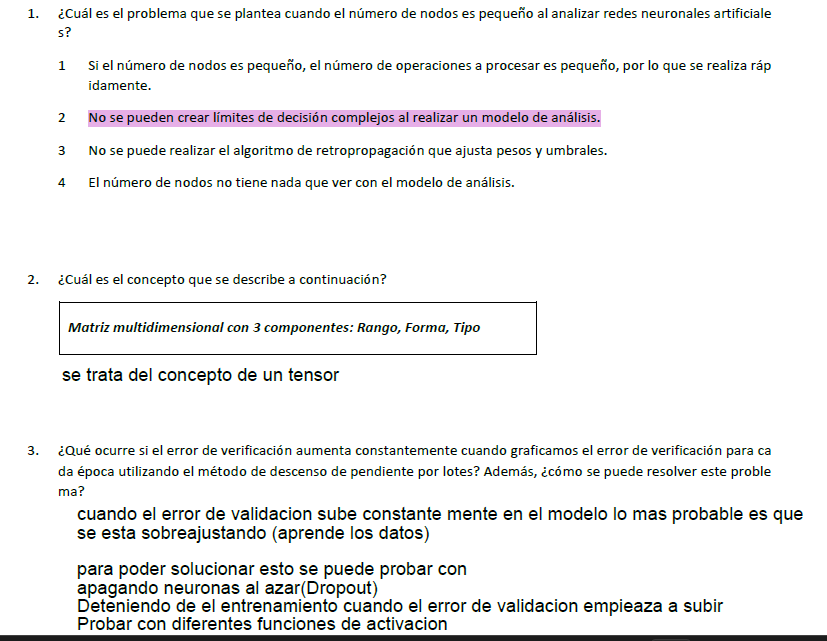

5. Aplicar la función softmax cuando la salida de la red neuronal es $\mathbf{x} = (0.4,\, 2.0,\, 0.001,\, 0.32)^T$ y escriba el resultado 

$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{4} e^{x_j}}
$$

$$
\sum_{j=1}^{4} e^{x_j} = e^{0.4} + e^{2.0} + e^{0.001} + e^{0.32}
\approx 11.259
$$

$$
\text{softmax}(\mathbf{x}) =
\left(
\frac{e^{0.4}}{11.259},\,
\frac{e^{2.0}}{11.259},\,
\frac{e^{0.001}}{11.259},\,
\frac{e^{0.32}}{11.259}
\right)^T
$$

$$
\text{softmax}(\mathbf{x}) \approx (0.133,\; 0.656,\; 0.089,\; 0.122)^T
$$

In [45]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
## Leemos los datos 
df = pd.read_csv('boston.csv', header='infer')
df = df[['PRICE']]

scaler = MinMaxScaler() ## Estandarizamos los datos del conjunto
ts_scaled = scaler.fit_transform(df)

## Scale
ts_scaled_2 = ts_scaled.reshape(1,-1,1)



In [ ]:
## Funcion que separa los datos en trenamiento y prueba con una ventana de tiempo dada 
def create_dataset(data, window_size=5):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [35]:
X_train, y_train = create_dataset(ts_scaled)

## parametros de entrenamiento 
batch_size = 1 
n_epochs = 1000
learn_rate = 0.0001


In [ ]:
## Creamos el modelo 
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(None,1)))
model.add(tf.keras.layers.LSTM(50, activation='relu', input_shape=(5,1)))
model.add(tf.keras.layers.Dense(1))


model.compile(optimizer='adam', loss='mse')

In [37]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## Entrenamos el modelo con los datos de entrenamiento 
model.fit( X_train,y_train, 
    epochs= n_epochs, 
    batch_size= batch_size)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


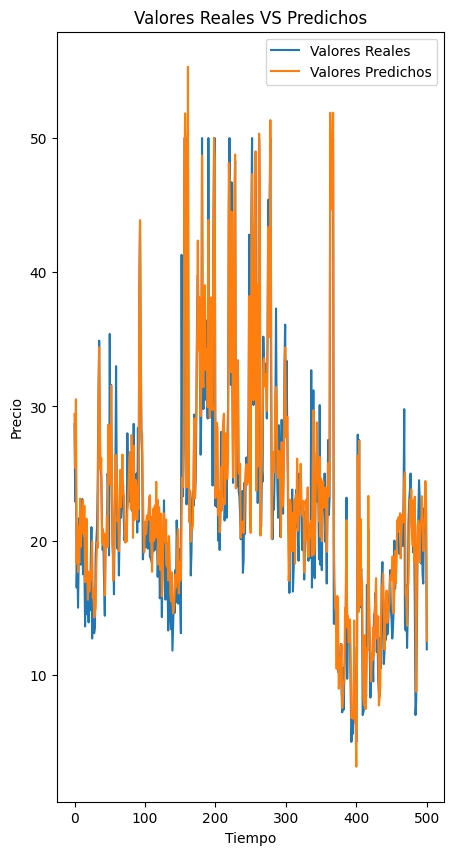

In [43]:
## Obtenemos los valors predichos por el modelo 
y_pred = model.predict(X_train)

## Como trabajamos con datos escalados debemos desescalar los datos 
y_train_inv = scaler.inverse_transform(y_train)
y_pred_inv = scaler.inverse_transform(y_pred)

## Graficamos los valores predicos contra los valores reales 

plt.figure(figsize=(5,10))
plt.plot(y_train_inv, label = 'Valores Reales')
plt.plot(y_pred_inv, label = 'Valores Predichos')

plt.title('Valores Reales VS Predichos')
plt.xlabel('Tiempo')
plt.ylabel('Precio')

plt.legend()
plt.show()

In [ ]:
#Obtenemos algunas metricas de error para poder evaluar el modelo 
mse = mean_squared_error(y_train_inv, y_pred_inv)
mae = mean_absolute_error(y_train_inv, y_pred_inv)

print("Error Cuadratico Medio (MSE) :", mse)
print("Error Absoluto Medio (MAE):", mae)

Error Cuadratico Medio (MSE) : 8.548832085561578
Error Absoluto Medio (MAE): 2.2160205690684673
